# Cu-64 nel nucleo: microdosimetria → MKM → LQ → S(N) e RBE(N)

Metti questo notebook nella **radice del progetto** (dove c'è la cartella `runs/`) ed esegui le celle in ordine.
Il passo lento è uno solo (la cella *"Campionamento delle dosi"*): il risultato viene salvato in `cache_dosi.npz`,
quindi puoi cambiare pesi, `alpha_0`, `beta`, `G` e rifare grafici e tabelle in pochi secondi.

## 0. Parametri

In [ ]:
import glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

# --- stile dei grafici (vale per tutto il notebook) ---
C_MAIN, C_ACC, C_TEAL = "#1D3557", "#E63946", "#2A9D8F"     # blu notte, rosso corallo, verde acqua
C_GOLD, C_GREY, C_INK = "#F4A261", "#8D99AE", "#2B2D42"     # arancio, grigio-azzurro, quasi nero
mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.facecolor": "#F8F9FB", "axes.edgecolor": "#BFC5D2", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": cycler(color=[C_MAIN, C_ACC, C_TEAL, C_GOLD, C_GREY]),
    "axes.grid": True, "grid.color": "#D5DAE3", "grid.linestyle": ":", "grid.linewidth": 0.8, "grid.alpha": 0.9,
    "xtick.color": C_INK, "ytick.color": C_INK, "axes.labelcolor": C_INK, "text.color": C_INK,
    "lines.linewidth": 1.8, "legend.frameon": True, "legend.framealpha": 0.9,
    "legend.edgecolor": "#D5DAE3", "legend.fontsize": 9,
})
CMAP_2D, CMAP_CORR = "YlGnBu", "RdBu_r"

FILES = sorted(glob.glob("runs/run_*/yz.root"))
TREE = "yz"

# --- modello ---
R_d, R_n = 0.420, 4.0        # um   raggio dominio (= /microyz/det/Radius) e raggio nucleo
y0 = 150.0                   # keV/um  saturazione MKM
alpha_0, beta = 0.147, 0.02  # Gy^-1, Gy^-2 (raggi X)
G = 1.0                      # Lea-Catcheside: 1 = dose istantanea, <1 se protratta.
                             # L'RBE e' sempre rispetto a raggi X con lo stesso G (isola l'effetto della qualita' della radiazione)
rho = 1e-15                  # kg/um^3
KEV_J, EV_J = 1.602176634e-16, 1.602176634e-19
S_TARGET = 0.10
K_CONV = KEV_J / (rho * np.pi * R_d**2)     # Gy per keV/um

# --- statistica ---
N_SIM = 400                  # cellule virtuali per pool
N_POINTS = 60                # punti sull'asse N
N_BOOT = 20                  # pool bootstrap (solo se hai UN file)
SEED = 12345
WEIGHT_MODES = ("N/n",)         # peso N/n = nbHits / nbScoredHits
PLOT_MODE = "N/n"

print(f"{len(FILES)} file trovati;  K_CONV = {K_CONV:.4f} Gy per keV/um")

10 file trovati;  K_CONV = 0.2891 Gy per keV/um


## 1. Lettura dei file

In [ ]:
import uproot

cols = ["y", "nbHits", "nbScoredHits", "Nuclear_dose"]
dfs = [uproot.open(f)[TREE].arrays(cols, library="pd") for f in FILES]
print("eventi per file:", [len(d) for d in dfs])
dfs[0].head()

eventi per file: [20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000]


,y,nbHits,nbScoredHits,Nuclear_dose
0,4.819198,599.0,295.0,3.212431e-03
1,0.371628,142.0,23.0,7.563023e-04
2,0.047345,3.0,3.0,1.584539e-05
3,1.590789,97.0,97.0,5.324053e-04
4,0.002043,1.0,1.0,6.837594e-07


## 2. Controlli
- **Allineamento:** l'energia nel nucleo (da `Nuclear_dose`) deve essere ≥ quella nel dominio (da `y`). Frazione attesa: 1.0000.
- **Seed:** i run devono avere eventi diversi.

In [ ]:
def check_alignment(df, label=""):
    m_nucl = 1e3 * 4/3 * np.pi * (R_n * 1e-6) ** 3
    e_nucl = df["Nuclear_dose"].to_numpy() * m_nucl / EV_J     # eV nel nucleo
    eps = df["y"].to_numpy() * (4 * R_d / 3 * 1000.0)          # eV nel dominio
    ok = np.mean(e_nucl >= eps * (1 - 1e-3) - 0.5)
    print(f"[check] {label}: righe coerenti = {ok:.4f}")
    return ok

check_ok = [check_alignment(d, f) for f, d in zip(FILES, dfs)]

seed_msg = "un solo file (non verificabile)"
if len(dfs) > 1:
    heads = [d["y"].to_numpy()[:200].tobytes() for d in dfs]
    seed_msg = "run tutti diversi" if len(set(heads)) == len(heads) else "ATTENZIONE: run identici, seed non cambiati!"
print("[seed]", seed_msg)

[check] runs/run_01/yz.root: righe coerenti = 1.0000
[check] runs/run_02/yz.root: righe coerenti = 1.0000
[check] runs/run_03/yz.root: righe coerenti = 1.0000
[check] runs/run_04/yz.root: righe coerenti = 1.0000
[check] runs/run_05/yz.root: righe coerenti = 1.0000
[check] runs/run_06/yz.root: righe coerenti = 1.0000
[check] runs/run_07/yz.root: righe coerenti = 1.0000
[check] runs/run_08/yz.root: righe coerenti = 1.0000
[check] runs/run_09/yz.root: righe coerenti = 1.0000
[check] runs/run_10/yz.root: righe coerenti = 1.0000
[seed] run tutti diversi


## 3. Pool (un pool = una simulazione indipendente)

In [ ]:
def make_pools(dfs, rng):
    if len(dfs) > 1:
        return dfs
    df = dfs[0]
    print(f"un solo file: uso {N_BOOT} pool bootstrap")
    return [df.iloc[rng.integers(0, len(df), len(df))].reset_index(drop=True) for _ in range(N_BOOT)]

rng = np.random.default_rng(SEED)
pools = make_pools(dfs, rng)
print(len(pools), "pool")

10 pool


## 4. Microdosimetria: y_F, y_D, y*
Per ogni pool, con il peso N/n. Gli errori (`sem`) sono tra pool.

In [ ]:
def weights(df, mode="N/n"):
    n = df["nbScoredHits"].to_numpy(float)       # hit nel dominio
    big_n = df["nbHits"].to_numpy(float)         # hit nel nucleo
    return big_n / n                             # peso N/n

def micro(df, mode):
    y = df["y"].to_numpy()
    w = weights(df, mode)
    y_f = np.sum(w * y) / np.sum(w)
    y_d = np.sum(w * y**2) / np.sum(w * y)
    y_star = np.sum(w * y0**2 * (1.0 - np.exp(-(y / y0) ** 2))) / np.sum(w * y)
    return y_f, y_d, y_star

rows = []
for i, p in enumerate(pools):
    for mode in WEIGHT_MODES:
        yf, yd, ys = micro(p, mode)
        rows.append(dict(pool=i, peso=mode, yF=yf, yD=yd, ystar=ys,
                         alpha=alpha_0 + beta * K_CONV * ys))
tab_micro = pd.DataFrame(rows)
tab_micro.groupby("peso")[["yF", "yD", "ystar", "alpha"]].agg(["mean", "sem"])

yF                 yD               ystar               alpha  \
          mean      sem      mean       sem      mean       sem      mean   
peso                                                                        
N/n   1.127767  0.00532  4.804801  0.010795  4.798184  0.010761  0.174744   

                
           sem  
peso            
N/n   0.000062

## 5. Spettri pesati f(y) e d(y) (tutti i run insieme)
Le linee verticali tratteggiate sono $y_F$ e $y_D$ calcolati nella cella 4 (media tra pool). Si disegnano verticali perché $y$ sta sull'asse x.

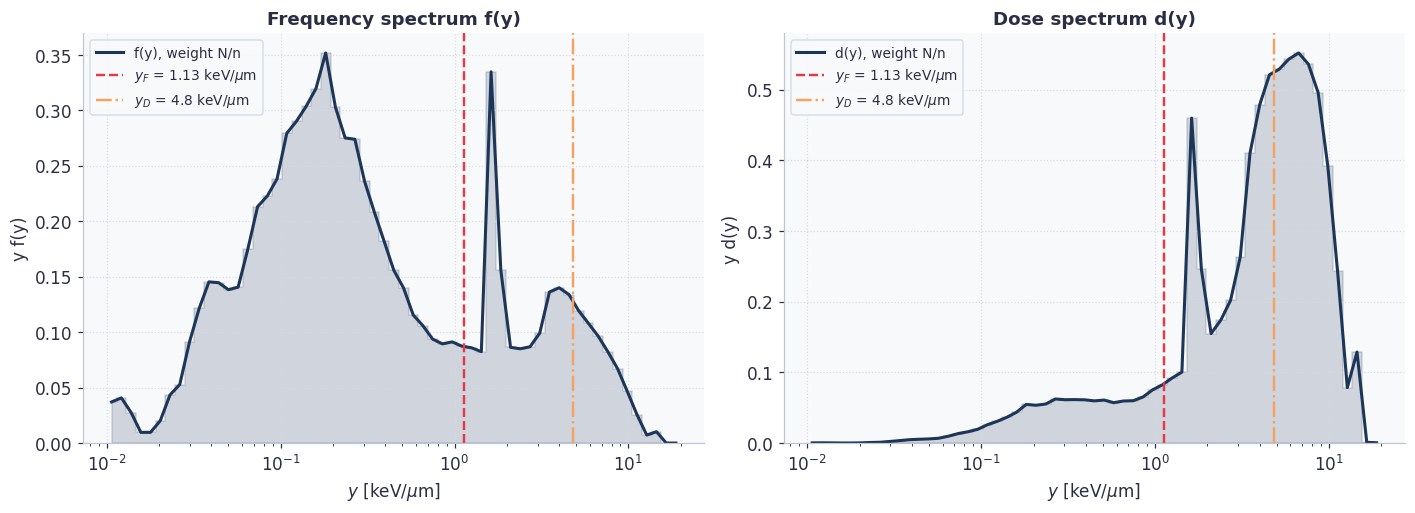

In [ ]:
allp = pd.concat(pools, ignore_index=True)
bins = np.logspace(-2, np.log10(20), 60)
x = np.sqrt(bins[:-1] * bins[1:])
dln = np.diff(np.log(bins))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for mode in WEIGHT_MODES:
    w = weights(allp, mode)
    y = allp["y"].to_numpy()
    f = np.histogram(y, bins=bins, weights=w)[0];     f = f / f.sum() / dln
    d = np.histogram(y, bins=bins, weights=w * y)[0]; d = d / d.sum() / dln

    # y_F e y_D calcolati nella cella 4 (media tra pool)
    yF_m = tab_micro.loc[tab_micro["peso"] == mode, "yF"].mean()
    yD_m = tab_micro.loc[tab_micro["peso"] == mode, "yD"].mean()

    for a_, curva, lab in ((ax[0], f, f"f(y), weight {mode}"), (ax[1], d, f"d(y), weight {mode}")):
        a_.fill_between(x, curva, color=C_MAIN, alpha=0.18, step="mid")
        a_.semilogx(x, curva, color=C_MAIN, lw=2.0, label=lab)
        a_.axvline(yF_m, color=C_ACC, ls="--", lw=1.6, label=rf"$y_F$ = {yF_m:.3g} keV/$\mu$m")
        a_.axvline(yD_m, color=C_GOLD, ls="-.", lw=1.6, label=rf"$y_D$ = {yD_m:.3g} keV/$\mu$m")

ax[0].set_ylabel("y f(y)"); ax[1].set_ylabel("y d(y)")
ax[0].set_title("Frequency spectrum f(y)"); ax[1].set_title("Dose spectrum d(y)")
for a_ in ax:
    a_.set_xlabel(r"$y$ [keV/$\mu$m]"); a_.set_ylim(bottom=0); a_.legend(loc="upper left")
plt.tight_layout(); plt.show()

### Confronto prima/dopo il peso N/n: distribuzioni di y e z
Per ciascuna grandezza, istogramma **non pesato** (grigio) e **pesato con N/n** (rosso) sovrapposti, stessi bin, entrambi normalizzati ad area 1 (in `ln x`), così la differenza di forma è visibile direttamente. Le linee verticali sono le medie (quella pesata è `y_F`, rispettivamente `z_F`).

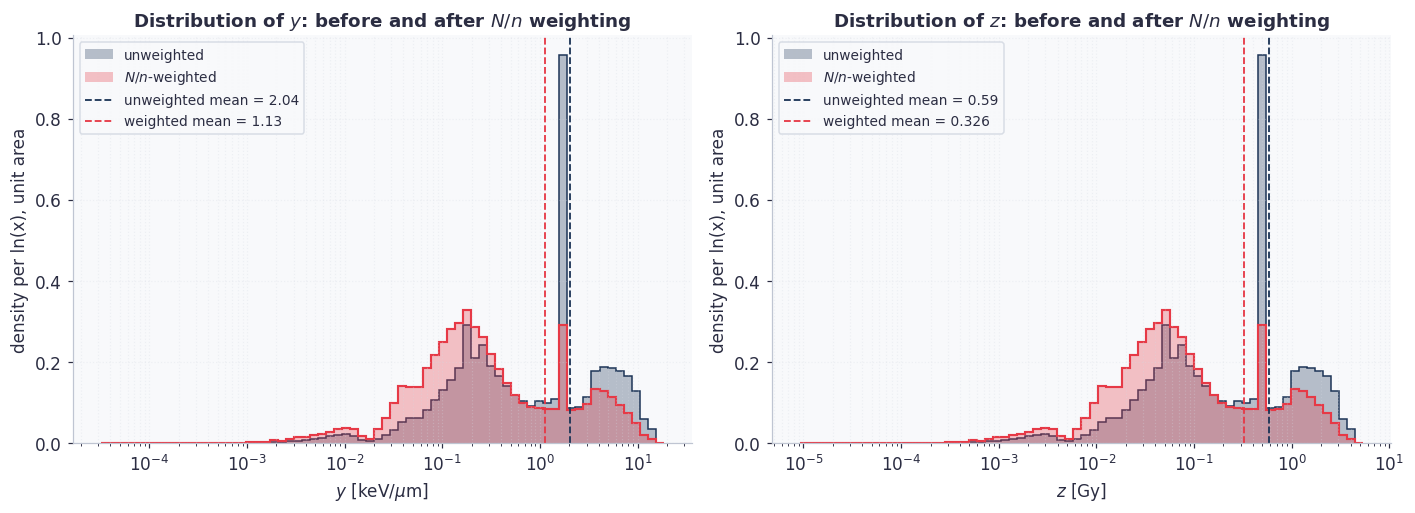

y: media non pesata = 2.0412, pesata (y_F) = 1.1276 keV/um  (rapporto 0.552)
z: media non pesata = 5.9014e-01, pesata (z_F) = 3.2601e-01 Gy      (rapporto 0.552)


In [ ]:
def overlay(ax, x, w, xlabel, nb=70):
    ok = x > 0                                   # scala log: gli eventuali zeri non si possono mostrare
    xp, wp = x[ok], w[ok]
    b = np.logspace(np.log10(xp.min()), np.log10(xp.max()), nb + 1)
    dln_ = np.diff(np.log(b))
    h0 = np.histogram(xp, bins=b)[0].astype(float)            # prima: peso 1
    h1 = np.histogram(xp, bins=b, weights=wp)[0]              # dopo: peso N/n
    h0 /= h0.sum() * dln_
    h1 /= h1.sum() * dln_
    ax.stairs(h0, b, fill=True, color=C_MAIN, alpha=0.30, label="unweighted")
    ax.stairs(h0, b, color=C_MAIN, lw=1.0)
    ax.stairs(h1, b, fill=True, color=C_ACC, alpha=0.30, label="$N/n$-weighted")
    ax.stairs(h1, b, color=C_ACC, lw=1.4)
    m0, m1 = xp.mean(), np.average(xp, weights=wp)
    ax.axvline(m0, color=C_MAIN, ls="--", lw=1.2, label=f"unweighted mean = {m0:.3g}")
    ax.axvline(m1, color=C_ACC, ls="--", lw=1.2, label=f"weighted mean = {m1:.3g}")
    ax.set_xscale("log"); ax.set_xlabel(xlabel); ax.set_ylabel("density per ln(x), unit area")
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)
    return m0, m1, (~ok).mean()

allp = pd.concat(pools, ignore_index=True)
w_Nn = weights(allp, "N/n")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
m0y, m1y, z0y = overlay(ax[0], allp["y"].to_numpy(), w_Nn, r"$y$ [keV/$\mu$m]")
z_all = allp["z"].to_numpy() if "z" in allp.columns else K_CONV * allp["y"].to_numpy()   # z = K_CONV * y
m0z, m1z, z0z = overlay(ax[1], z_all, w_Nn, r"$z$ [Gy]")
ax[0].set_title("Distribution of $y$: before and after $N/n$ weighting")
ax[1].set_title("Distribution of $z$: before and after $N/n$ weighting")
plt.tight_layout()
fig.savefig("confronto_peso_y_z.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"y: media non pesata = {m0y:.4f}, pesata (y_F) = {m1y:.4f} keV/um  (rapporto {m1y / m0y:.3f})")
print(f"z: media non pesata = {m0z:.4e}, pesata (z_F) = {m1z:.4e} Gy      (rapporto {m1z / m0z:.3f})")
if z0y > 0 or z0z > 0:
    print(f"eventi con valore 0 esclusi dal grafico: y {100 * z0y:.2f}%, z {100 * z0z:.2f}%")

## 5b. Esplorazione dei dati grezzi: istogrammi 1D e 2D (tutti i run)
Qui si leggono **tutte** le colonne dei `.root` (non solo le quattro usate dal modello) e si aggiungono alcune grandezze derivate
(energie in keV, rapporto `nbScoredHits/nbHits`, il peso N/n). I grafici sono pensati per trarre conclusioni:
- **1D:** ogni variabile, con ogni run in blu e la media dei run in nero (se i run coincidono, la statistica è stabile).
- **2D a matrice:** tutte le coppie di variabili, con la correlazione di Spearman nel triangolo alto.
- **2D mirati:** le coppie con un significato fisico, con le rette di riferimento (limiti, proporzionalità).

In [ ]:
import uproot
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

CYTO_THICK = 1.0     # um  (= /microyz/det/setCytoThickness)

def read_all(f):
    return uproot.open(f)[TREE].arrays(library="pd")          # TUTTE le colonne del tree

full = pd.concat([read_all(f).assign(run=i + 1) for i, f in enumerate(FILES)], ignore_index=True)

# --- grandezze derivate ---
m_nucl = 1e3 * 4/3 * np.pi * (R_n * 1e-6) ** 3                                        # kg
m_cyto = 1e3 * 4/3 * np.pi * (((R_n + CYTO_THICK) * 1e-6) ** 3 - (R_n * 1e-6) ** 3)   # kg
full["E_nucl_keV"]  = full["Nuclear_dose"] * m_nucl / KEV_J        # energia depositata nel nucleo
full["E_cyto_keV"]  = full["Cytoplasmic_dose"] * m_cyto / KEV_J    # energia depositata nel citoplasma
full["eps_dom_keV"] = full["y"] * (4 * R_d / 3)                    # energia nel dominio (y * l_medio)
full["ratio"]       = full["nbScoredHits"] / full["nbHits"]
full["w_Nn"]        = full["nbHits"] / full["nbScoredHits"]

num = full.drop(columns="run")
stat = pd.DataFrame({"media": num.mean(), "mediana": num.median(), "std": num.std(),
                     "min": num.min(), "max": num.max(), "frazione = 0": (num == 0).mean()})
const = [c for c in num.columns if num[c].nunique() == 1]

print(f"{len(full)} eventi totali in {len(FILES)} file")
print("colonne costanti (non plottate):", {c: float(num[c].iloc[0]) for c in const})
stat.drop(index=const).round(5)

200000 eventi totali in 10 file
colonne costanti (non plottate): {'eventID': 0.0, 'radius': 420.0, 'Einc': 0.0}


,media,mediana,std,min,max,frazione = 0
nbHits,279.84144,101.00000,358.31993,1.00000,4286.00000,0.00000
nbScoredHits,125.30326,59.00000,169.20989,1.00000,1143.00000,0.00000
y,2.04122,0.96191,2.74588,0.00003,18.56029,0.00000
z,0.59014,0.27810,0.79386,0.00001,5.36595,0.00000
Nuclear_dose,0.00154,0.00054,0.00194,0.00000,0.02363,0.00000
Cytoplasmic_dose,0.00030,0.00007,0.00079,0.00000,0.01415,0.40414
E_nucl_keV,2.57874,0.90789,3.24986,0.00002,39.53404,0.00000
E_cyto_keV,0.48547,0.11606,1.25589,0.00000,22.56737,0.40414
eps_dom_keV,1.14308,0.53867,1.53769,0.00002,10.39376,0.00000
ratio,0.55137,0.50000,0.33773,0.00136,1.00000,0.00000


### 1D: ogni variabile
Linee blu = singoli run (conteggi per run), linea nera = media dei run. Asse y sempre logaritmico.

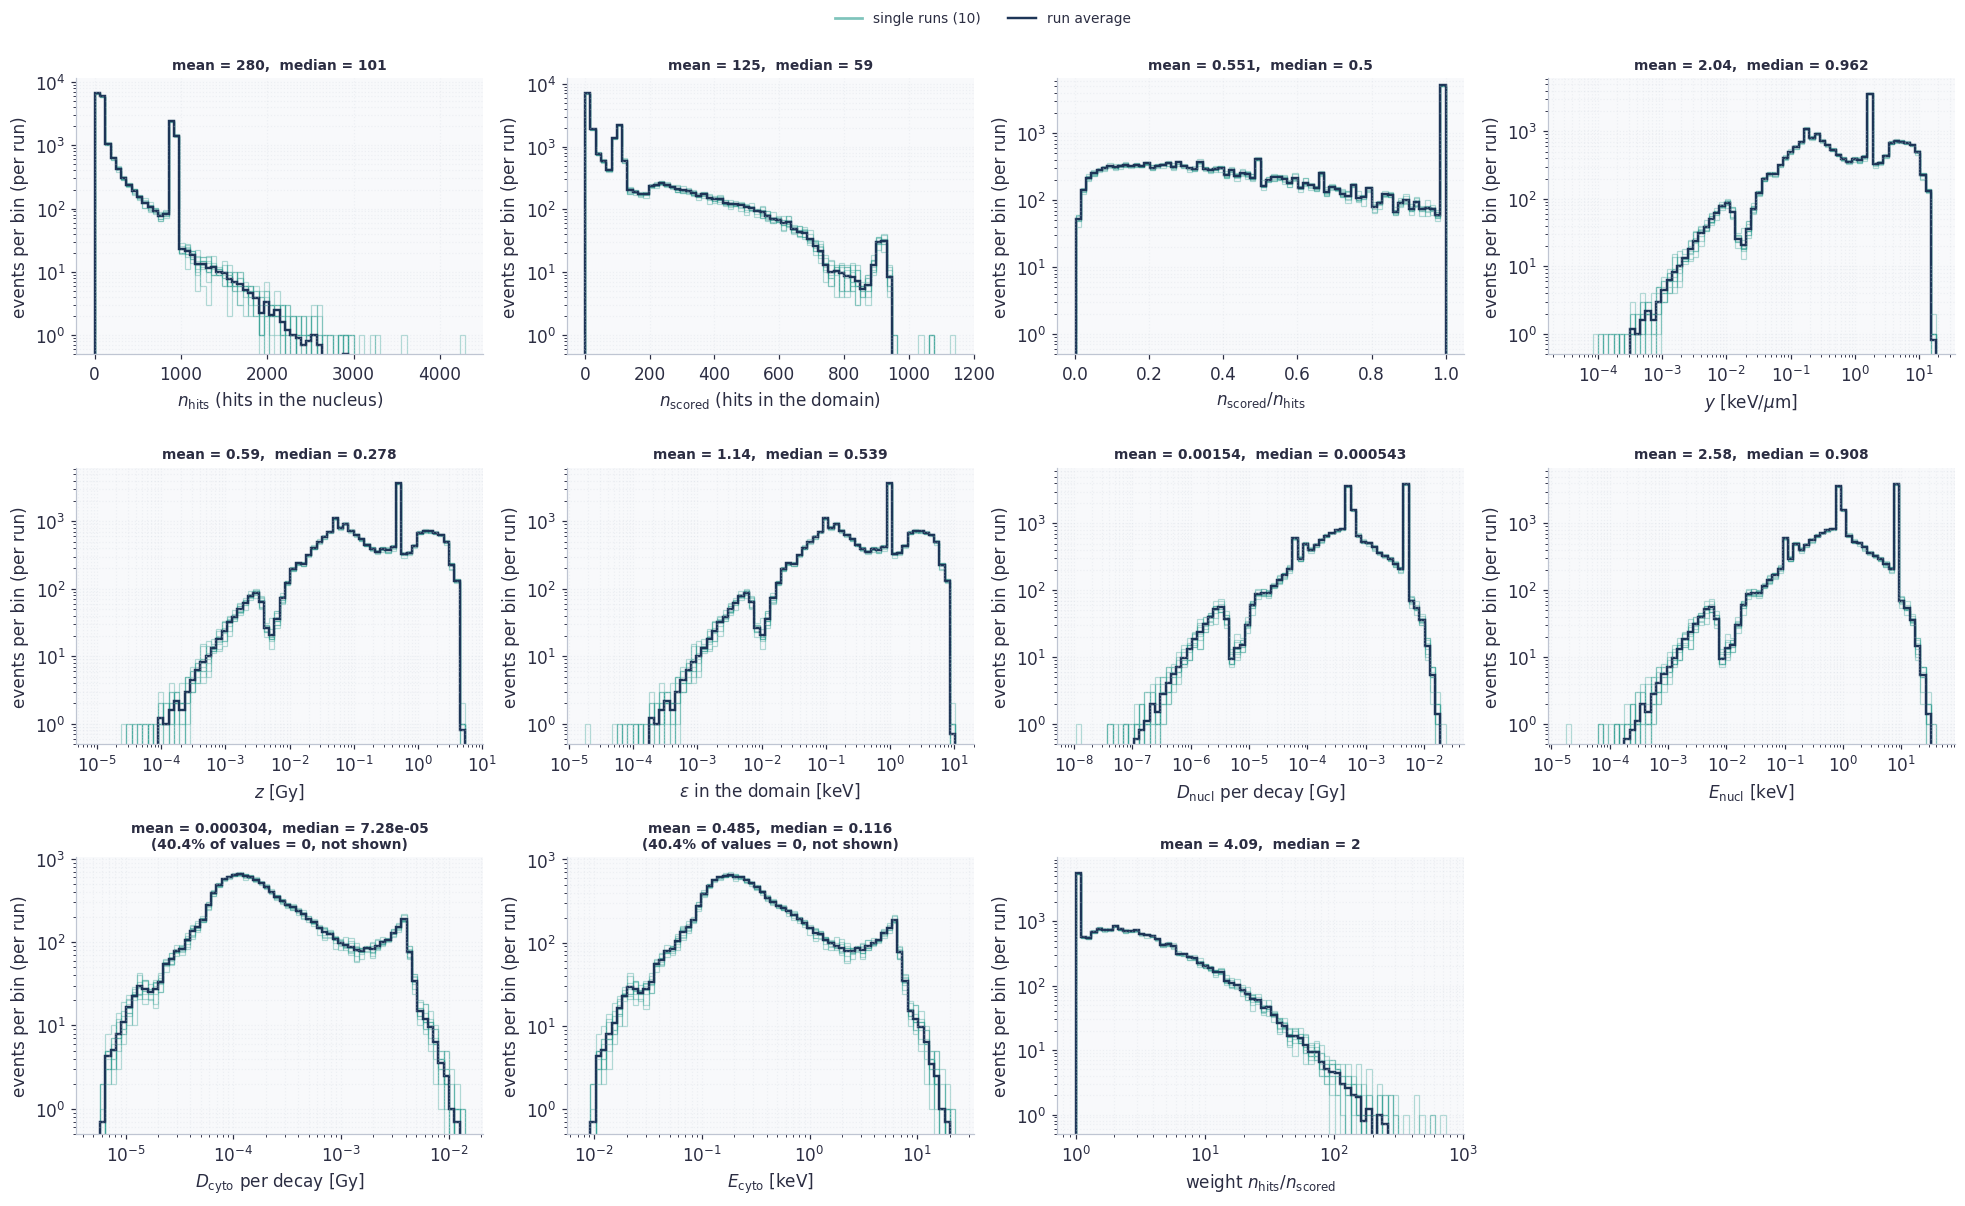

In [ ]:
runs = sorted(full["run"].unique())

PANELS = [   # (colonna, etichetta asse x, scala x)
    ("nbHits",           r"$n_{\rm hits}$ (hits in the nucleus)",          "lin"),
    ("nbScoredHits",     r"$n_{\rm scored}$ (hits in the domain)",       "lin"),
    ("ratio",            r"$n_{\rm scored}/n_{\rm hits}$",           "lin"),
    ("y",                r"$y$ [keV/$\mu$m]",                         "log"),
    ("z",                r"$z$ [Gy]",                                  "log"),
    ("eps_dom_keV",      r"$\varepsilon$ in the domain [keV]",          "log"),
    ("Nuclear_dose",     r"$D_{\rm nucl}$ per decay [Gy]",      "log"),
    ("E_nucl_keV",       r"$E_{\rm nucl}$ [keV]",                     "log"),
    ("Cytoplasmic_dose", r"$D_{\rm cyto}$ per decay [Gy]",      "log"),
    ("E_cyto_keV",       r"$E_{\rm cyto}$ [keV]",                     "log"),
    ("w_Nn",             r"weight $n_{\rm hits}/n_{\rm scored}$",      "log"),
]

def make_bins(x, scale, nb=70):
    x = x[np.isfinite(x)]
    if scale == "log":
        x = x[x > 0]
        return np.logspace(np.log10(x.min()), np.log10(x.max()), nb + 1)
    return np.linspace(x.min(), x.max(), nb + 1)

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, (col, lab, scale) in zip(axes.ravel(), PANELS):
    x_all = full[col].to_numpy()
    bins = make_bins(x_all, scale)
    H = np.array([np.histogram(full.loc[full["run"] == r, col], bins=bins)[0] for r in runs])
    for h in H:
        ax.stairs(h, bins, color=C_TEAL, alpha=0.35, lw=0.8)
    ax.stairs(H.mean(axis=0), bins, color=C_MAIN, lw=1.6)
    ax.set_yscale("log")
    ax.set_ylim(bottom=0.5)
    if scale == "log":
        ax.set_xscale("log")
    ax.set_xlabel(lab)
    ax.set_ylabel("events per bin (per run)")
    z0 = np.mean(x_all == 0)
    ax.set_title(f"mean = {x_all.mean():.3g},  median = {np.median(x_all):.3g}"
                 + (f"\n({100 * z0:.1f}% of values = 0, not shown)" if z0 > 0 else ""), fontsize=9)
    ax.grid(alpha=0.3, which="both")

for ax in axes.ravel()[len(PANELS):]:
    ax.axis("off")

fig.legend(handles=[Line2D([], [], color=C_TEAL, alpha=0.6, label=f"single runs ({len(runs)})"),
                    Line2D([], [], color=C_MAIN, lw=1.6, label="run average")],
           loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("hist1d_tutte_le_variabili.png", dpi=150, bbox_inches="tight")
plt.show()

### 2D: tutte le coppie (matrice)
Triangolo basso: istogrammi 2D (scala di colore logaritmica, tutti gli eventi di tutti i run). Diagonale: istogramma 1D.
Triangolo alto: correlazione di Spearman (misura la monotonia, quindi regge bene anche con distribuzioni a code lunghe).
Tutte le variabili sono in `log10`; i valori **uguali a 0** (ad es. la dose citoplasmatica) sono messi nel bin più a sinistra, e il nome
dell'asse ha un asterisco.

* Cytoplasmic_dose: 40.4% dei valori sono 0 (nel bin piu' a sinistra)


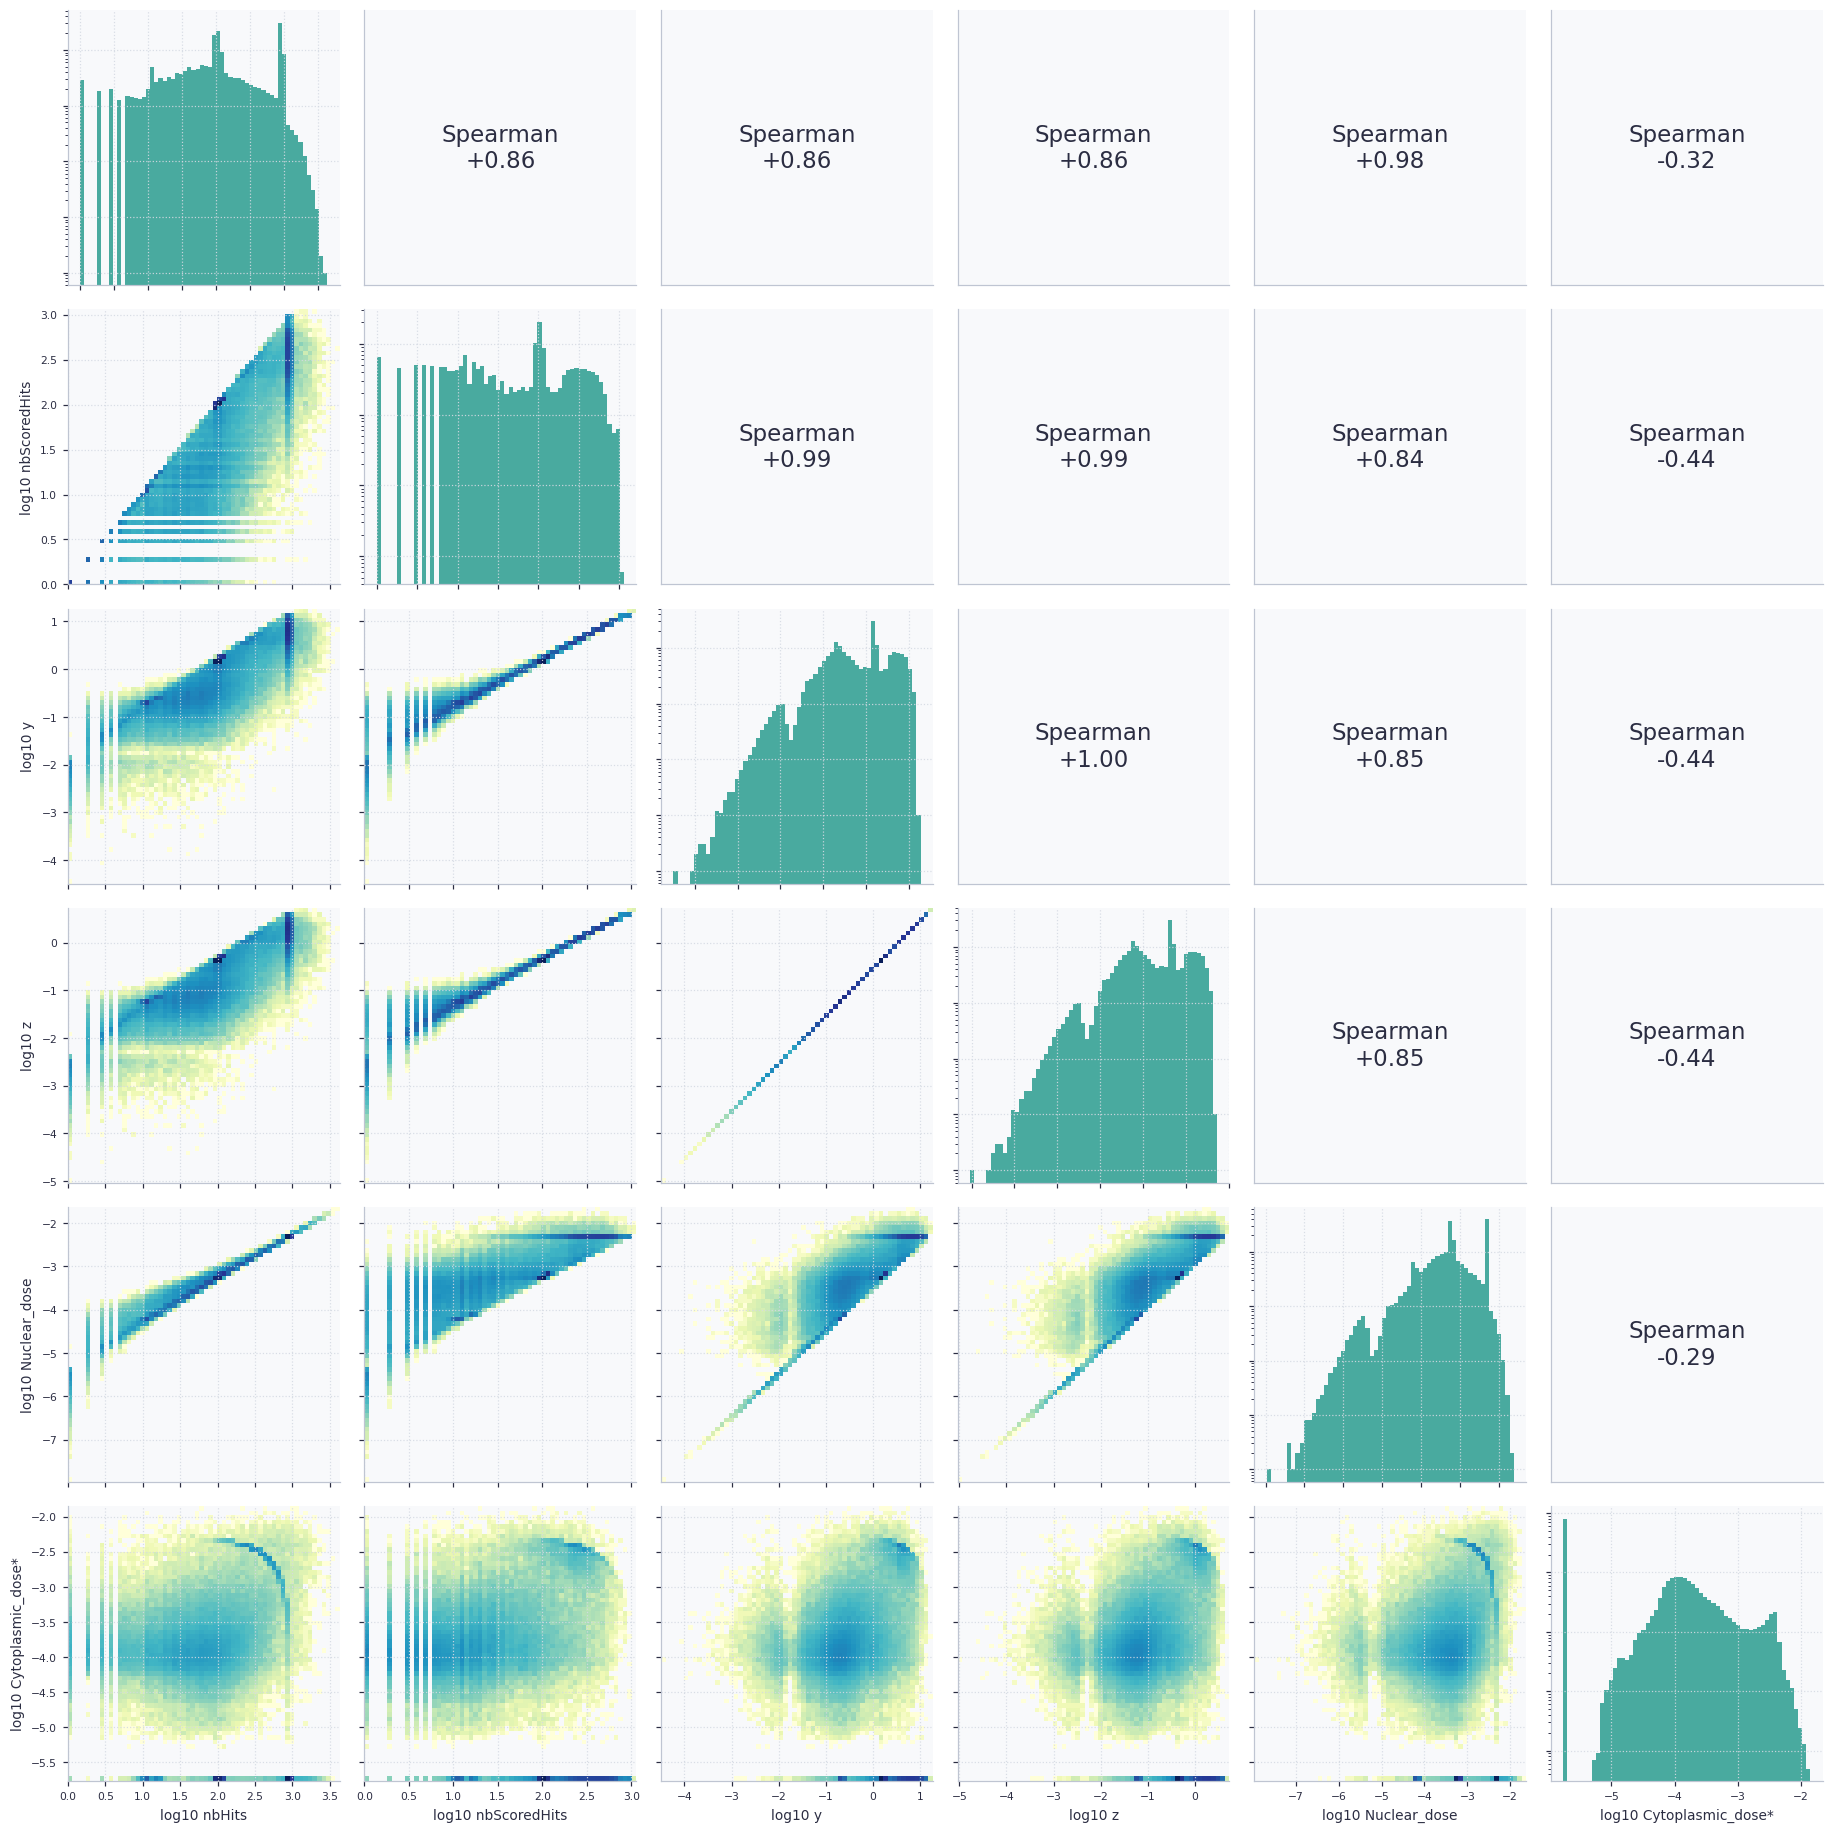

In [ ]:
PAIR_VARS = ["nbHits", "nbScoredHits", "y", "z", "Nuclear_dose", "Cytoplasmic_dose"]   # modificabile

def to_log(x):
    """log10 con gli zeri messi sotto il minimo positivo (floor = min/3). Restituisce anche la frazione di zeri."""
    x = np.asarray(x, float)
    pos = x > 0
    floor = x[pos].min() / 3.0
    return np.log10(np.where(pos, x, floor)), float((~pos).mean())

L, zfrac = {}, {}
for c in PAIR_VARS:
    L[c], zfrac[c] = to_log(full[c].to_numpy())
rho_s = full[PAIR_VARS].corr(method="spearman")

n = len(PAIR_VARS)
fig, axes = plt.subplots(n, n, figsize=(2.8 * n, 2.8 * n))
for i, ci in enumerate(PAIR_VARS):            # riga  -> asse y
    for j, cj in enumerate(PAIR_VARS):        # colonna -> asse x
        ax = axes[i, j]
        if i == j:
            ax.hist(L[ci], bins=60, color=C_TEAL, alpha=0.85)
            ax.set_yscale("log")
        elif i > j:
            ax.hist2d(L[cj], L[ci], bins=60, norm=LogNorm(), cmin=1, cmap=CMAP_2D)
        else:
            ax.text(0.5, 0.5, f"Spearman\n{rho_s.loc[ci, cj]:+.2f}", ha="center", va="center",
                    fontsize=15, transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
        ax.tick_params(labelsize=7, labelbottom=(i == n - 1), labelleft=(j == 0 and i > 0))
        if i == n - 1:
            ax.set_xlabel("log10 " + cj + ("*" if zfrac[cj] > 0 else ""), fontsize=9)
        if j == 0 and i > 0:
            ax.set_ylabel("log10 " + ci + ("*" if zfrac[ci] > 0 else ""), fontsize=9)

for c in PAIR_VARS:
    if zfrac[c] > 0:
        print(f"* {c}: {100 * zfrac[c]:.1f}% dei valori sono 0 (nel bin piu' a sinistra)")
plt.tight_layout()
fig.savefig("hist2d_matrice.png", dpi=150, bbox_inches="tight")
plt.show()

### 2D mirati, con le rette di riferimento
Ognuno di questi grafici ha un significato fisico preciso:
- `n_scored` vs `n_hits`: la sfera non può contenere più hit del nucleo (retta `n = N`).
- `E_nucl` vs `ε_dominio`: l'energia nel nucleo non può essere minore di quella nel dominio (retta `E = ε`; la frazione sotto la retta deve essere 0).
- `E_nucl` vs `n_hits`: l'energia è circa proporzionale al numero di hit (energia media per hit).
- `E_cyto` vs `E_nucl`: gli eventi che depositano energia fuori dal nucleo.
- `z` vs `y`: proporzionalità esatta `z = K_CONV · y`.
- `y` vs `n_scored` / `n_hits`, e il peso `N/n` vs `y`: servono per discutere i pesi.

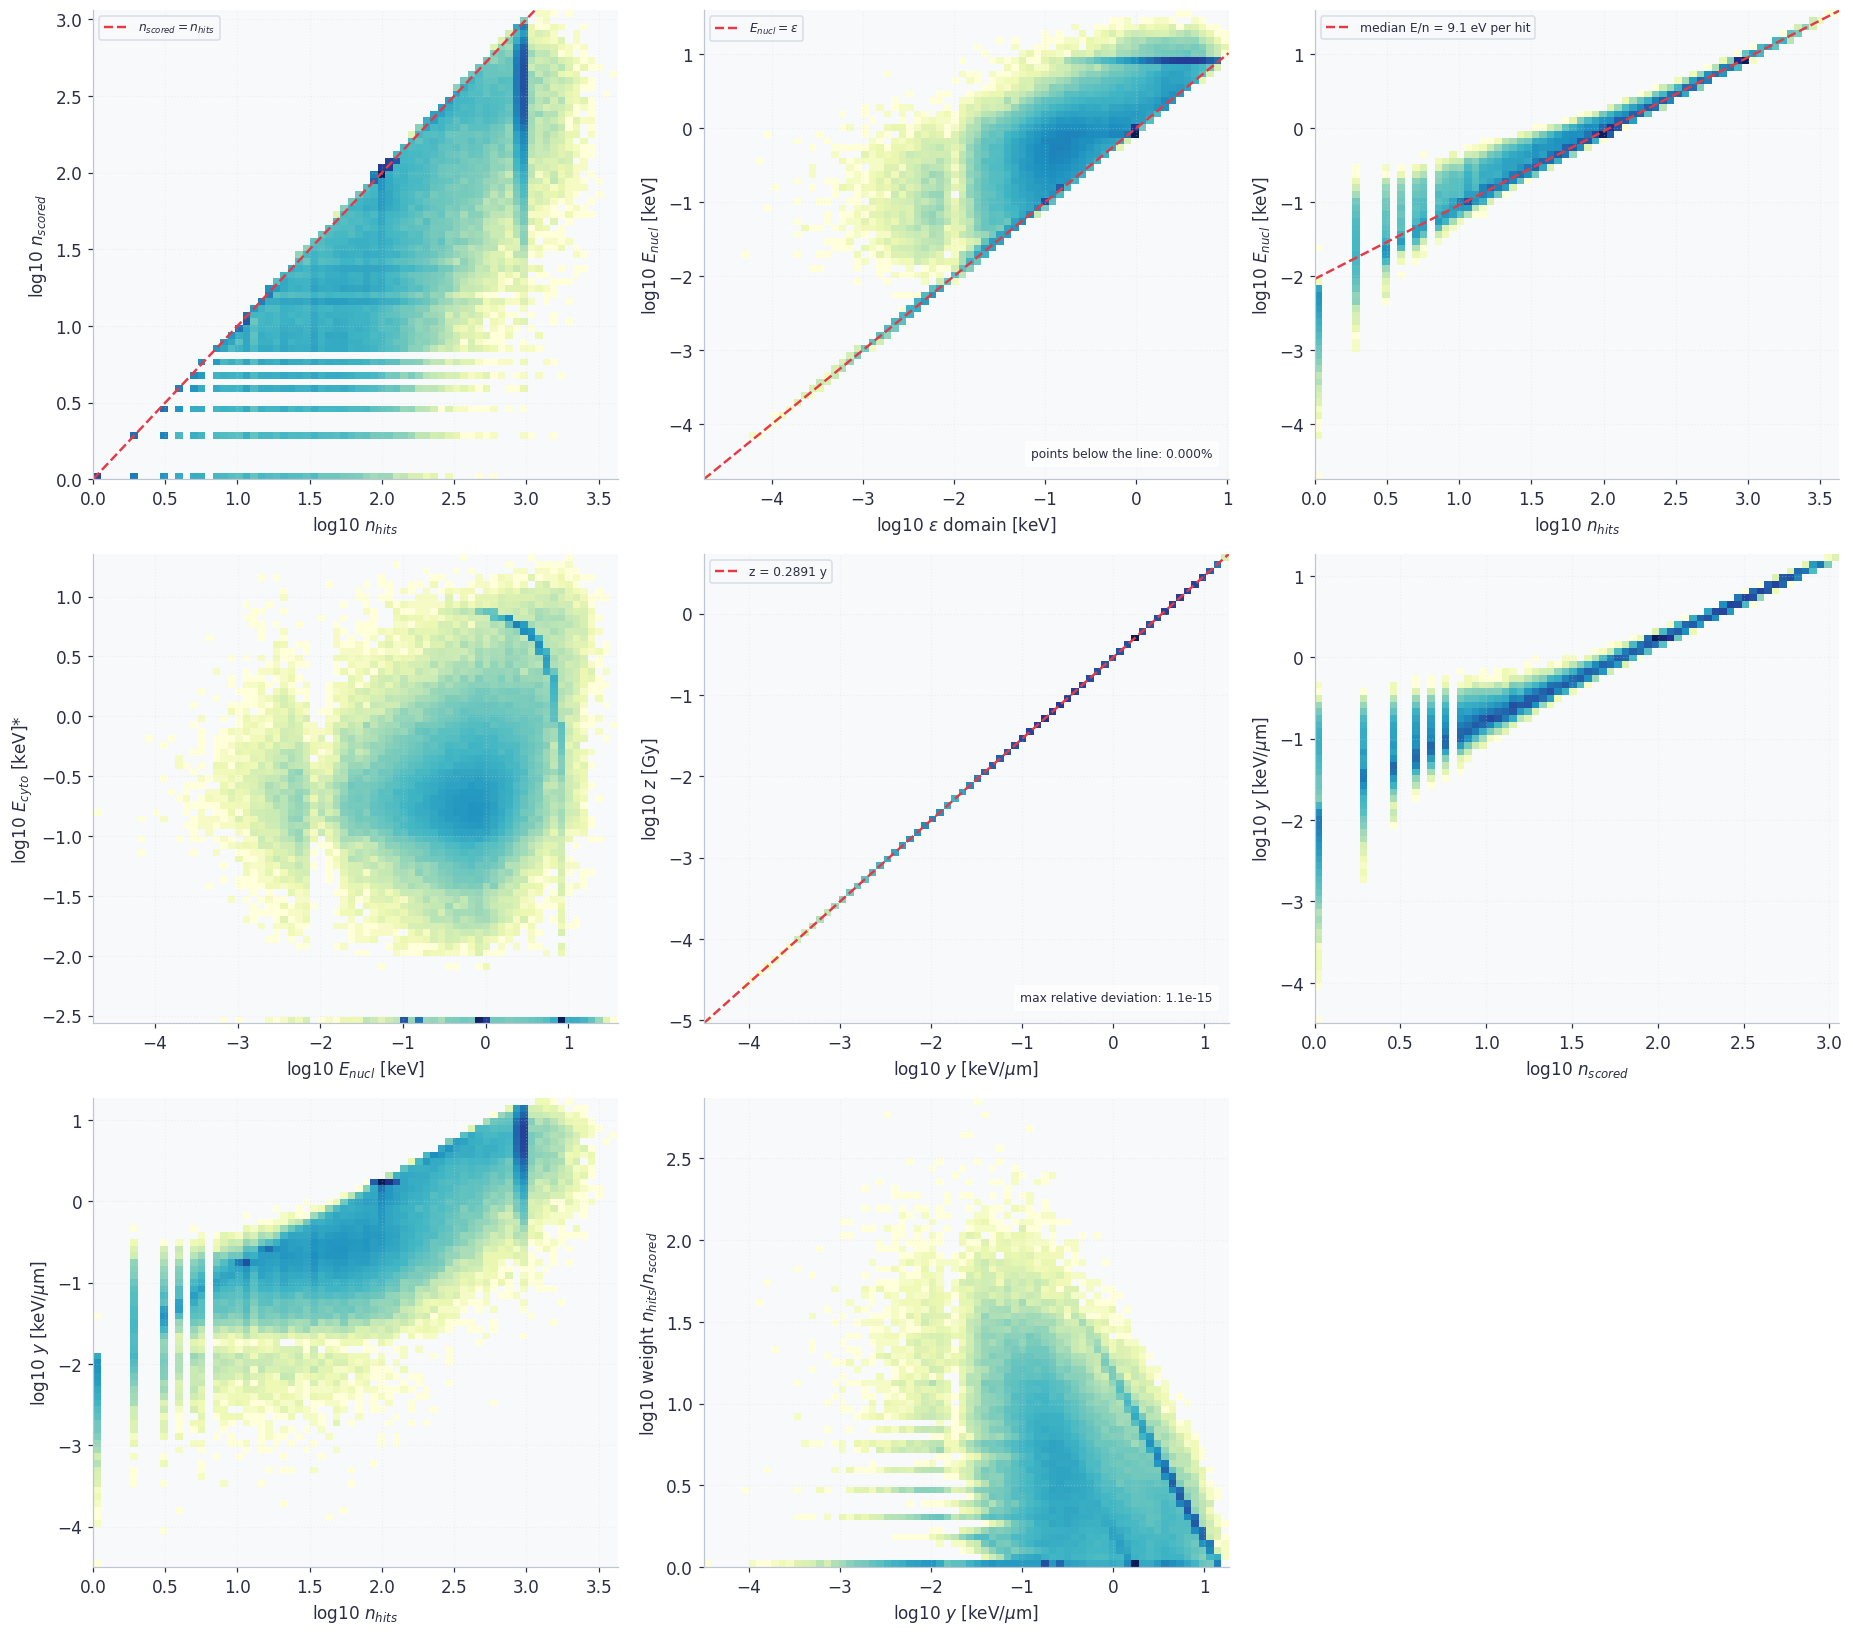

In [ ]:
def panel(ax, xcol, ycol, xlab, ylab, ref=None, ref_label=None, note=None, nb=70):
    xl, xz = to_log(full[xcol].to_numpy())
    yl, yz = to_log(full[ycol].to_numpy())
    ax.hist2d(xl, yl, bins=nb, norm=LogNorm(), cmin=1, cmap=CMAP_2D)
    ax.set_xlabel("log10 " + xlab + ("*" if xz > 0 else ""))
    ax.set_ylabel("log10 " + ylab + ("*" if yz > 0 else ""))
    if ref is not None:
        xs = np.array(ax.get_xlim())
        ax.plot(xs, ref(xs), "--", color=C_ACC, lw=1.6, label=ref_label)
        ax.set_xlim(*xs)
        ax.legend(loc="upper left", fontsize=8)
    if note:
        ax.text(0.97, 0.04, note, transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
                bbox=dict(fc="white", alpha=0.75, lw=0))
    ax.grid(alpha=0.3)

viol = np.mean(full["E_nucl_keV"] < full["eps_dom_keV"] * (1 - 1e-3) - 5e-4)
dev_z = np.max(np.abs(full["z"] / (K_CONV * full["y"]) - 1))
k_eh = np.median(full["E_nucl_keV"] / full["nbHits"])            # keV per hit

fig, axes = plt.subplots(3, 3, figsize=(17, 15))
panel(axes[0, 0], "nbHits", "nbScoredHits", r"$n_{hits}$", r"$n_{scored}$",
      ref=lambda x: x, ref_label=r"$n_{scored} = n_{hits}$")
panel(axes[0, 1], "eps_dom_keV", "E_nucl_keV", r"$\varepsilon$ domain [keV]", r"$E_{nucl}$ [keV]",
      ref=lambda x: x, ref_label=r"$E_{nucl} = \varepsilon$", note=f"points below the line: {100 * viol:.3f}%")
panel(axes[0, 2], "nbHits", "E_nucl_keV", r"$n_{hits}$", r"$E_{nucl}$ [keV]",
      ref=lambda x: x + np.log10(k_eh), ref_label=f"median E/n = {k_eh * 1e3:.1f} eV per hit")
panel(axes[1, 0], "E_nucl_keV", "E_cyto_keV", r"$E_{nucl}$ [keV]", r"$E_{cyto}$ [keV]")
panel(axes[1, 1], "y", "z", r"$y$ [keV/$\mu$m]", r"$z$ [Gy]",
      ref=lambda x: x + np.log10(K_CONV), ref_label=f"z = {K_CONV:.4f} y",
      note=f"max relative deviation: {dev_z:.1e}")
panel(axes[1, 2], "nbScoredHits", "y", r"$n_{scored}$", r"$y$ [keV/$\mu$m]")
panel(axes[2, 0], "nbHits", "y", r"$n_{hits}$", r"$y$ [keV/$\mu$m]")
panel(axes[2, 1], "y", "w_Nn", r"$y$ [keV/$\mu$m]", r"weight $n_{hits}/n_{scored}$")
axes[2, 2].axis("off")

plt.tight_layout()
fig.savefig("hist2d_mirati.png", dpi=150, bbox_inches="tight")
plt.show()

### Correlazioni (tabella e mappa)
Correlazione di Spearman tra tutte le variabili numeriche interessanti. Utile per vedere subito cosa dipende da cosa.

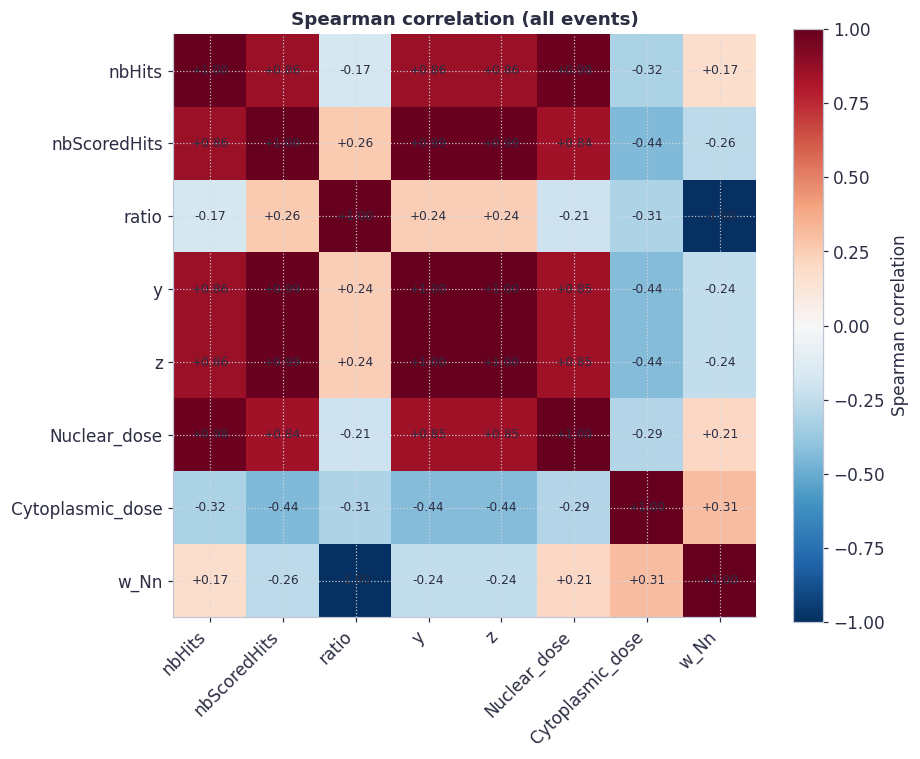

,nbHits,nbScoredHits,ratio,y,z,Nuclear_dose,Cytoplasmic_dose,w_Nn
nbHits,1.000,0.864,-0.173,0.860,0.860,0.982,-0.315,0.173
nbScoredHits,0.864,1.000,0.258,0.991,0.991,0.840,-0.441,-0.258
ratio,-0.173,0.258,1.000,0.245,0.245,-0.207,-0.307,-1.000
y,0.860,0.991,0.245,1.000,1.000,0.848,-0.436,-0.245
z,0.860,0.991,0.245,1.000,1.000,0.848,-0.436,-0.245
Nuclear_dose,0.982,0.840,-0.207,0.848,0.848,1.000,-0.294,0.207
Cytoplasmic_dose,-0.315,-0.441,-0.307,-0.436,-0.436,-0.294,1.000,0.307
w_Nn,0.173,-0.258,-1.000,-0.245,-0.245,0.207,0.307,1.000


In [ ]:
CORR_VARS = ["nbHits", "nbScoredHits", "ratio", "y", "z", "Nuclear_dose", "Cytoplasmic_dose", "w_Nn"]
rho_all = full[CORR_VARS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(rho_all.values, cmap=CMAP_CORR, vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_VARS))); ax.set_xticklabels(CORR_VARS, rotation=45, ha="right")
ax.set_yticks(range(len(CORR_VARS))); ax.set_yticklabels(CORR_VARS)
for i in range(len(CORR_VARS)):
    for j in range(len(CORR_VARS)):
        ax.text(j, i, f"{rho_all.values[i, j]:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="Spearman correlation")
ax.set_title("Spearman correlation (all events)")
plt.tight_layout()
fig.savefig("correlazioni.png", dpi=150, bbox_inches="tight")
plt.show()
rho_all.round(3)

## 5c. Range dei positroni (β⁺) dagli istogrammi dei `.root`
`SteppingAction` riempie tre istogrammi a ogni vera annichilazione di un positrone (processo `annihil`):
- `r_creation`: distanza dal centro del nucleo del punto di emissione;
- `r_annihilation`: distanza dal centro del punto di annichilazione;
- `displacement`: distanza tra emissione e annichilazione (il **range** in linea d'aria, non la lunghezza del percorso).

**Attenzione al binning.** Nei run vecchi `CreateH1(..., 400, 0., 2000., "um")` passava gli estremi in unità interne di Geant4 (mm), quindi l'asse arrivava a 2000 mm
con bin da 5 mm: tutti i positroni cadevano nel primo bin e il range non si misura. Nel `RunAction` va scritto, ad esempio, `3.*mm` o `5.*um` (vedi la chat).
Per questo la cella legge i file da `runs_beta/run_*/yz.root` (run con i nuovi istogrammi) e avvisa se trova bin troppo larghi.

Controlli utili: positroni per decadimento ≈ 0.175 (ramo β⁺ del Cu-64) e frazione in overflow (positroni oltre il limite dell'asse).

file usati: ['runs/run_01/yz.root', 'runs/run_02/yz.root', 'runs/run_03/yz.root', 'runs/run_04/yz.root', 'runs/run_05/yz.root', 'runs/run_06/yz.root', 'runs/run_07/yz.root', 'runs/run_08/yz.root', 'runs/run_09/yz.root', 'runs/run_10/yz.root']
oggetti nel primo file: ['yz;1', 'r_creation;1', 'r_annihilation;1', 'displacement;1']
larghezza bin = 5.0 um  (le quantita' sono note a +/- un bin)


,media,sem
positroni_per_decadimento,0.1754,0.0012
media_um,540.7110,2.4744
mediana_um,460.9667,3.5716
p95_um,1292.1729,6.7402
p99_um,1642.8867,8.8390
max_um,2175.5000,32.9937
frazione_overflow,0.0000,0.0000
frazione_nel_primo_bin,0.0015,0.0002


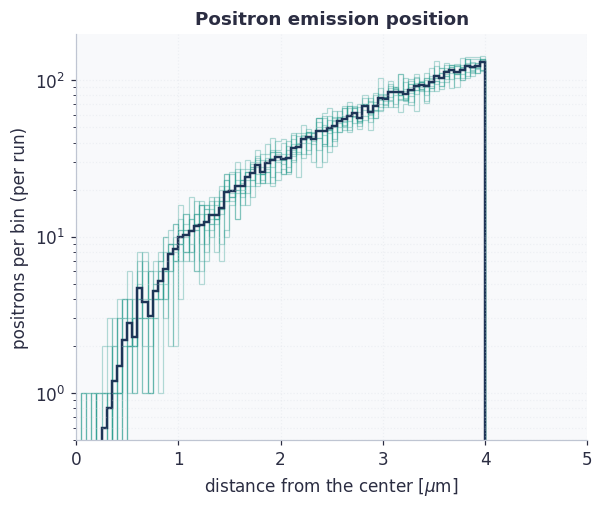

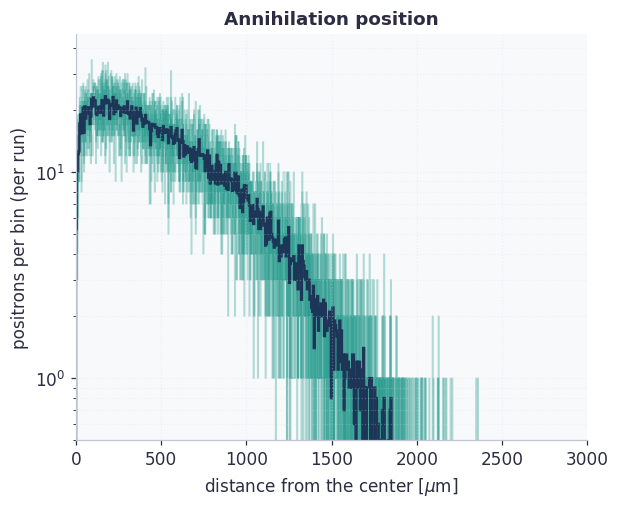

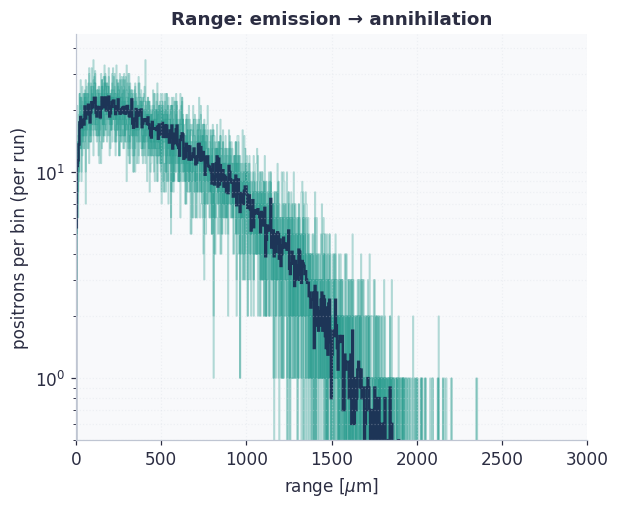

In [ ]:
FILES_LIST = sorted(glob.glob("runs/run_*/yz.root")) or FILES     # run con i nuovi istogrammi (cartella runs_beta/)
n_events = [uproot.open(f)[TREE].num_entries for f in FILES_LIST]       # decadimenti per run

print("file usati:", FILES_LIST)
print("oggetti nel primo file:", uproot.open(FILES_LIST[0]).keys())     # controllo: devono esserci i 3 istogrammi

def read_h1(f, name):
    h = uproot.open(f)[name]
    counts, edges = h.to_numpy()
    try:
        entries = float(h.member("fEntries"))    # tutti i riempimenti, compresi quelli fuori range
    except Exception:
        entries = np.nan
    return counts.astype(float), np.asarray(edges, float), entries

NAMES = ["r_creation", "r_annihilation", "displacement"]
H = {}
for name in NAMES:
    cs, es = [], []
    for f in FILES_LIST:
        c, edges, e = read_h1(f, name)
        cs.append(c); es.append(e)
    H[name] = dict(counts=np.array(cs), edges=edges, entries=np.array(es))
x = 0.5 * (H["displacement"]["edges"][:-1] + H["displacement"]["edges"][1:])     # um
bin_w = np.diff(H["displacement"]["edges"])[0]
if bin_w > 50:
    print(f"ATTENZIONE: bin larghi {bin_w:.0f} um (asse fino a {H['displacement']['edges'][-1]:.3g} um): "
          "istogrammi con il binning vecchio, il range NON e' misurabile. Rifai il run con RunAction corretto (vedi testo).")

# --- statistiche del range (distanza emissione -> annichilazione) per ogni run ---
rows = []
for k, (c, ent, nev) in enumerate(zip(H["displacement"]["counts"], H["displacement"]["entries"], n_events)):
    tot = c.sum()
    cum = np.cumsum(c) / tot
    up = H["displacement"]["edges"][1:]
    rows.append(dict(
        run=k + 1,
        positroni_per_decadimento=ent / nev,
        media_um=np.sum(c * x) / tot,
        mediana_um=np.interp(0.50, cum, up),
        p95_um=np.interp(0.95, cum, up),
        p99_um=np.interp(0.99, cum, up),
        max_um=up[np.nonzero(c)[0].max()],
        frazione_overflow=(ent - tot) / ent,
        frazione_nel_primo_bin=c[0] / tot))
tab_beta = pd.DataFrame(rows).set_index("run")
print(f"larghezza bin = {bin_w:.1f} um  (le quantita' sono note a +/- un bin)")
summary = pd.DataFrame({"media": tab_beta.mean(), "sem": tab_beta.sem()})
display(summary.round(4))

# --- grafici individuali e salvataggio/download ---
titles = {"r_creation": "Positron emission position",
          "r_annihilation": "Annihilation position",
          "displacement": "Range: emission → annihilation"}

saved_files = []

for name in NAMES:
    fig, a_ = plt.subplots(figsize=(6, 4.8))
    ed = H[name]["edges"]; cc = H[name]["counts"]
    for c in cc:
        a_.stairs(c, ed, color=C_TEAL, alpha=0.35, lw=0.8)
    a_.stairs(cc.mean(axis=0), ed, color=C_MAIN, lw=1.6)
    a_.set_yscale("log"); a_.set_ylim(bottom=0.5)
    a_.set_xlabel(r"distance from the center [$\mu$m]" if name != "displacement" else r"range [$\mu$m]")
    a_.set_ylabel("positrons per bin (per run)")
    a_.set_xlim(0, min(ed[-1], 3500))
    a_.set_title(titles[name]); a_.grid(alpha=0.3, which="both")
    
    # Linee di riferimento aggiuntive per il plot di displacement

## 6. Campionamento delle dosi (passo lento, una volta sola)
Ogni cellula virtuale accumula decadimenti uno dopo l'altro; la dose a N decadimenti è la somma cumulata delle dosi nucleari.
Una sola estrazione per cellula serve per tutti gli N.

In [ ]:
def d_ref_at(s_target, g=None):
    """Dose di raggi X (alpha_0, beta*g) per avere S = s_target. Stesso G della radiazione studiata."""
    g = G if g is None else g
    b = beta * g
    return (-alpha_0 + np.sqrt(alpha_0**2 - 4 * b * np.log(s_target))) / (2 * b)

def sample_doses(dn, ns, rng):
    n_max = int(ns.max())
    idx = rng.integers(0, dn.size, size=(N_SIM, n_max), dtype=np.int32)
    cum = np.cumsum(dn[idx], axis=1)
    return cum[:, ns - 1].T                      # shape (len(ns), N_SIM)

dn_mean = np.mean([p["Nuclear_dose"].mean() for p in pools])
n_max = int(3 * d_ref_at(S_TARGET) / dn_mean)
ns = np.unique(np.linspace(1, n_max, N_POINTS).astype(int))
print(f"dose nucleare media per decadimento = {dn_mean:.3e} Gy ;  N da 1 a {n_max}")

t0 = time.time()
d_mats = []
for i, p in enumerate(pools):
    d_mats.append(sample_doses(p["Nuclear_dose"].to_numpy(), ns, rng))
    print(f"pool {i + 1}/{len(pools)}  ({time.time() - t0:.0f} s)")
d_mats = np.array(d_mats)                       # (pool, N, cellule)
np.savez("cache_dosi.npz", ns=ns, d_mats=d_mats)

dose nucleare media per decadimento = 1.541e-03 Gy ;  N da 1 a 14923
pool 1/10  (0 s)
pool 2/10  (0 s)
pool 3/10  (0 s)
pool 4/10  (0 s)
pool 5/10  (0 s)
pool 6/10  (0 s)
pool 7/10  (0 s)
pool 8/10  (0 s)
pool 9/10  (0 s)
pool 10/10  (1 s)


*Solo se riavvii il kernel:* non rifare il campionamento, ricarica la cache (e rilancia le celle 0-4).

In [ ]:
# cache = np.load("cache_dosi.npz"); ns = cache["ns"]; d_mats = cache["d_mats"]

## 7. LQ + MKM: S(N), RBE(N), N10, D10 (veloce)

In [ ]:
def lq(d_mat, alpha, g=None):
    g = G if g is None else g
    e = alpha * d_mat + beta * g * d_mat**2
    s = np.exp(-e)
    d_ref = (-alpha_0 + np.sqrt(alpha_0**2 + 4 * beta * g * e)) / (2 * beta * g)   # raggi X con lo stesso G
    rbe = np.where(d_mat > 0, d_ref / np.where(d_mat > 0, d_mat, 1.0), np.nan)
    return s, rbe

def crossing(ns, s_mean, d_mean, target=S_TARGET):
    if s_mean.min() > target:
        return np.nan, np.nan                    # S non arriva al target nella griglia
    s = np.maximum(np.minimum.accumulate(s_mean), 1e-300)
    ls = np.log(s)
    return (np.interp(np.log(target), ls[::-1], ns[::-1]),
            np.interp(np.log(target), ls[::-1], d_mean[::-1]))

def analyze(df, d_mat, mode, g=None):
    g = G if g is None else g
    y_f, y_d, y_star = micro(df, mode)
    alpha = alpha_0 + beta * K_CONV * y_star
    s, rbe = lq(d_mat, alpha, g)
    s_mean, d_mean = s.mean(axis=1), d_mat.mean(axis=1)
    n10, d10 = crossing(ns, s_mean, d_mean)
    return dict(S=s_mean, S_cell=s.std(axis=1),
                rbe=np.nanmean(rbe, axis=1), rbe_cell=np.nanstd(rbe, axis=1), D=d_mean,
                yF=y_f, yD=y_d, ystar=y_star, alpha=alpha,
                N10=n10, D10=d10, rbe10=d_ref_at(S_TARGET, g) / d10, rbe_max=alpha / alpha_0)

def aggregate(results):
    k = len(results)
    agg = {}
    for key in ("S", "rbe", "D"):
        arr = np.array([r[key] for r in results])
        agg[key] = arr.mean(axis=0)
        agg[key + "_sem"] = arr.std(axis=0, ddof=1) / np.sqrt(k)
    for key in ("S_cell", "rbe_cell"):
        agg[key] = np.mean([r[key] for r in results], axis=0)
    for key in ("yF", "yD", "ystar", "alpha", "N10", "D10", "rbe10", "rbe_max"):
        v = np.array([r[key] for r in results])
        agg[key] = v.mean()
        agg[key + "_sem"] = v.std(ddof=1) / np.sqrt(k)
    return agg

results = {m: [analyze(p, dm, m) for p, dm in zip(pools, d_mats)] for m in WEIGHT_MODES}
agg = {m: aggregate(results[m]) for m in WEIGHT_MODES}

tab = pd.DataFrame({
    m: {"y_F": a["yF"], "y_D": a["yD"], "y*": a["ystar"], "alpha": a["alpha"], "RBE(D->0)": a["rbe_max"],
        "N10": a["N10"], "N10 sem": a["N10_sem"], "D10 [Gy]": a["D10"], "D10 sem": a["D10_sem"],
        "RBE10": a["rbe10"], "RBE10 sem": a["rbe10_sem"]}
    for m, a in agg.items()}).T
print(f"Dose X di riferimento per S=10%: {d_ref_at(S_TARGET):.4f} Gy")
tab

Dose X di riferimento per S=10%: 7.6667 Gy


,y_F,y_D,y*,alpha,RBE(D->0),N10,N10 sem,D10 [Gy],D10 sem,RBE10,RBE10 sem
N/n,1.127767,4.804801,4.798184,0.174744,1.188735,4684.724246,16.972022,7.218345,0.000942,1.062118,0.000139


## 8. Grafico: sopravvivenza e RBE

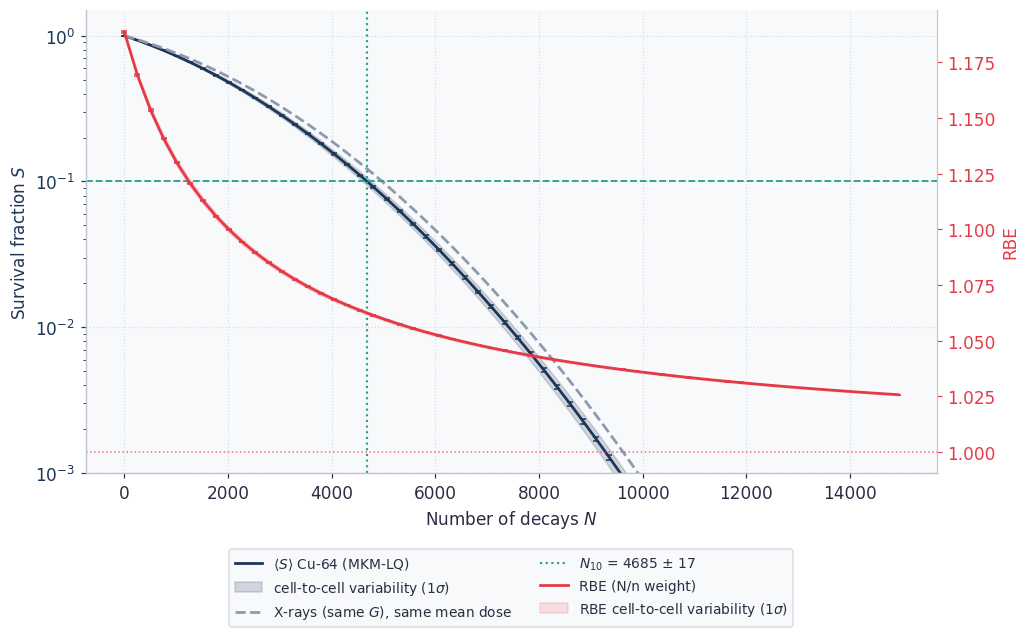

In [ ]:
a = agg[PLOT_MODE]
fig, ax1 = plt.subplots(figsize=(9.5, 6))
ax2 = ax1.twinx()                                   # secondo asse y (a destra) per l'RBE
ax2.grid(False); ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color("#BFC5D2")

# --- sopravvivenza S(N), asse sinistro (scala log)
l1, = ax1.plot(ns, a["S"], color=C_MAIN, label=r"$\langle S\rangle$ Cu-64 (MKM-LQ)")
b1 = ax1.fill_between(ns, np.clip(a["S"] - a["S_cell"], 1e-12, None), a["S"] + a["S_cell"],
                      color=C_MAIN, alpha=0.18, label=r"cell-to-cell variability ($1\sigma$)")
ax1.errorbar(ns, a["S"], yerr=a["S_sem"], fmt="none", ecolor=C_MAIN, elinewidth=0.8, capsize=2)
l2, = ax1.plot(ns, np.exp(-alpha_0 * a["D"] - beta * G * a["D"] ** 2), "--", color=C_GREY,
               label="X-rays (same $G$), same mean dose")
ax1.axhline(S_TARGET, color=C_TEAL, ls="--", lw=1.2)
l3 = ax1.axvline(a["N10"], color=C_TEAL, ls=":", lw=1.4,
                 label=f"$N_{{10}}$ = {a['N10']:.0f} ± {a['N10_sem']:.0f}")
ax1.set_yscale("log"); ax1.set_ylim(1e-3, 1.5)
ax1.set_xlabel("Number of decays $N$")
ax1.set_ylabel("Survival fraction $S$", color=C_MAIN)
ax1.tick_params(axis="y", colors=C_MAIN)

# --- RBE(N), asse destro (scala lineare)
l4, = ax2.plot(ns, a["rbe"], color=C_ACC, label=f"RBE ({PLOT_MODE} weight)")
b2 = ax2.fill_between(ns, a["rbe"] - a["rbe_cell"], a["rbe"] + a["rbe_cell"], color=C_ACC, alpha=0.15,
                      label=r"RBE cell-to-cell variability ($1\sigma$)")
ax2.errorbar(ns, a["rbe"], yerr=a["rbe_sem"], fmt="none", ecolor=C_ACC, elinewidth=0.8, capsize=2)
l5 = ax2.axhline(1.0, color=C_ACC, ls=":", lw=1.0, alpha=0.7)
ax2.set_ylabel("RBE", color=C_ACC)
ax2.tick_params(axis="y", colors=C_ACC)

# legenda unica sotto il grafico
handles = [l1, b1, l2, l3, l4, b2]
ax1.legend(handles=handles, labels=[h.get_label() for h in handles], loc="upper center",
           bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)

plt.tight_layout(); plt.savefig("cu64_S_RBE.png", dpi=200, bbox_inches="tight"); plt.show()

## 9. (Opzionale) Effetto della riparazione: scansione di G
Dose protratta in ore (emivita del Cu-64 ≈ 12.7 h) → il termine quadratico si riduce (`G < 1`). L'RBE resta rispetto a raggi X con lo stesso `G`.
Usa la cache delle dosi, quindi è istantaneo. Con `G` piccolo S può non arrivare al 10% nella griglia di N: in quel caso compare `NaN`.

In [ ]:
rows = []
for g in (1.0, 0.5, 0.2, 0.1, 0.05):
    res = [analyze(p, dm, PLOT_MODE, g=g) for p, dm in zip(pools, d_mats)]
    n10 = np.array([r["N10"] for r in res]); r10 = np.array([r["rbe10"] for r in res])
    rows.append(dict(G=g, N10=np.nanmean(n10), N10_sem=np.nanstd(n10, ddof=1) / np.sqrt(len(n10)),
                     RBE10=np.nanmean(r10)))
tab_G = pd.DataFrame(rows)
tab_G

,G,N10,N10_sem,RBE10
0,1.00,4684.724246,16.972022,1.062118
1,0.50,5694.138477,20.541106,1.083833
2,0.20,6881.848363,25.077221,1.116897
3,0.10,7548.090381,27.705471,1.140721
4,0.05,7990.346208,29.266511,1.159573


## 10. Riepilogo da copiare
Stampa in testo tutti i risultati delle celle precedenti, così puoi incollarli in una volta sola.

In [ ]:
a = agg[PLOT_MODE]
allp = pd.concat(pools, ignore_index=True)
yy = allp["y"].to_numpy()

print("=" * 78)
print("RIEPILOGO ANALISI Cu-64")
print("=" * 78)
print(f"File: {len(FILES)} | eventi per file: {[len(d) for d in dfs]}")
print(f"Check allineamento (frazione righe coerenti): {[round(float(c), 4) for c in check_ok]}")
print(f"Seed: {seed_msg}")
print(f"Parametri: R_d={R_d} um, R_n={R_n} um, y0={y0}, alpha_0={alpha_0}, beta={beta}, G={G}, K_CONV={K_CONV:.4f}")
print(f"Statistica: N_SIM={N_SIM}, N_POINTS={N_POINTS}, pool={len(pools)}, N max={int(ns.max())}")
print(f"Dose nucleare media per decadimento = {dn_mean:.4e} Gy")
print(f"Dose X di riferimento per S=10%: {d_ref_at(S_TARGET):.4f} Gy")

print("\n--- Distribuzione di y (tutti i run) ---")
print(f"y: media={yy.mean():.4f}, mediana={np.median(yy):.4f}, max={yy.max():.3f} keV/um")
for mode in WEIGHT_MODES:
    w = weights(allp, mode)
    print(f"peso {mode:>3}: eventi con y>10 keV/um = {np.mean(yy > 10):.4f} (non pesato), "
          f"{w[yy > 10].sum() / w.sum():.4f} (pesato)")

print("\n--- Microdosimetria (media e sem tra pool) ---")
print(tab_micro.groupby("peso")[["yF", "yD", "ystar", "alpha"]].agg(["mean", "sem"]).round(5).to_string())

print("\n--- Risultati finali per schema di peso ---")
print(tab.round(5).to_string())

print(f"\n--- Curva S(N), RBE(N) (peso {PLOT_MODE}), 10 punti ---")
sel = np.linspace(0, len(ns) - 1, 10).astype(int)
curve = pd.DataFrame({
    "N": ns[sel], "D_media[Gy]": a["D"][sel],
    "S": a["S"][sel], "S_sem": a["S_sem"][sel], "S_cell": a["S_cell"][sel],
    "RBE": a["rbe"][sel], "RBE_sem": a["rbe_sem"][sel], "RBE_cell": a["rbe_cell"][sel]})
print(curve.round(5).to_string(index=False))

print(f"\n--- Scansione G (peso {PLOT_MODE}) ---")
try:
    print(tab_G.round(4).to_string(index=False))
except NameError:
    print("(cella 9 non eseguita)")

RIEPILOGO ANALISI Cu-64
File: 10 | eventi per file: [20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000, 20000]
Check allineamento (frazione righe coerenti): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Seed: run tutti diversi
Parametri: R_d=0.42 um, R_n=4.0 um, y0=150.0, alpha_0=0.147, beta=0.02, G=1.0, K_CONV=0.2891
Statistica: N_SIM=400, N_POINTS=60, pool=10, N max=14923
Dose nucleare media per decadimento = 1.5412e-03 Gy
Dose X di riferimento per S=10%: 7.6667 Gy

--- Distribuzione di y (tutti i run) ---
y: media=2.0412, mediana=0.9619, max=18.560 keV/um
peso N/n: eventi con y>10 keV/um = 0.0234 (non pesato), 0.0073 (pesato)

--- Microdosimetria (media e sem tra pool) ---
           yF               yD            ystar             alpha         
         mean      sem    mean     sem     mean      sem     mean      sem
peso                                                                      
N/n   1.12777  0.00532  4.8048  0.0108  4.79818  0.01076  0.17474  0.0000

Qui come ultima istanza proviamo a dare un significato a quelli che sono i casi limite di creazione di domini parziamente al di fuori del nucleo.

In [ ]:
import numpy as np, uproot

t = uproot.open("yz.root")["yz"].arrays(library="np")
w = t["nbHits"] / t["nbScoredHits"]
y = t["y"]
r = t["r_domain_center"]            # um
y0, Rd, Rn = 150.0, 0.42, 4.0

def ystar(m):
    return y0**2 * np.sum(w[m] * (1 - np.exp(-y[m]**2 / y0**2))) / np.sum(w[m] * y[m])

intero = r + Rd <= Rn               # dominio tutto dentro il nucleo
print("frazione di domini troncati:", 1 - intero.mean())
print("y* tutti:", ystar(np.ones_like(r, dtype=bool)))
print("y* solo non troncati:", ystar(intero))